In [3]:
import pandas as pd
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
print(df.columns.tolist())
df.head()

['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## Data Cleaning

In [6]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

print("\nFuel types:", df['fuel'].unique())
print("Seller types:", df['seller_type'].unique())
print("Transmission types:", df['transmission'].unique())
print("Owner types:", df['owner'].unique())

Shape: (4340, 8)

Missing values:
 name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate rows: 763

Fuel types: <StringArray>
['Petrol', 'Diesel', 'CNG', 'LPG', 'Electric']
Length: 5, dtype: str
Seller types: <StringArray>
['Individual', 'Dealer', 'Trustmark Dealer']
Length: 3, dtype: str
Transmission types: <StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str
Owner types: <StringArray>
[         'First Owner',         'Second Owner', 'Fourth & Above Owner',
          'Third Owner',       'Test Drive Car']
Length: 5, dtype: str


In [7]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (3577, 8)


## Feature Engineering

In [8]:
current_year = datetime.now().year
df['car_age'] = current_year - df['year']

df['brand'] = df['name'].apply(lambda x: x.split()[0])

print(df[['name', 'brand', 'year', 'car_age']].head())
print("\nUnique brands:", df['brand'].nunique())
print(df['brand'].value_counts())

                       name    brand  year  car_age
0             Maruti 800 AC   Maruti  2007       19
1  Maruti Wagon R LXI Minor   Maruti  2007       19
2      Hyundai Verna 1.6 SX  Hyundai  2012       14
3    Datsun RediGO T Option   Datsun  2017        9
4     Honda Amaze VX i-DTEC    Honda  2014       12

Unique brands: 29
brand
Maruti           1072
Hyundai           637
Mahindra          328
Tata              308
Ford              220
Honda             216
Toyota            170
Chevrolet         151
Renault           110
Volkswagen         93
Nissan             52
Skoda              49
Fiat               32
Audi               31
Datsun             29
BMW                25
Mercedes-Benz      21
Jaguar              5
Mitsubishi          5
Land                5
Volvo               4
Jeep                3
Ambassador          3
MG                  2
OpelCorsa           2
Daewoo              1
Force               1
Isuzu               1
Kia                 1
Name: count, dtype: int64

In [9]:
df = df.drop(['name', 'year'], axis=1)
df.head()

,selling_price,km_driven,fuel,seller_type,transmission,owner,car_age,brand
0,60000,70000,Petrol,Individual,Manual,First Owner,19,Maruti
1,135000,50000,Petrol,Individual,Manual,First Owner,19,Maruti
2,600000,100000,Diesel,Individual,Manual,First Owner,14,Hyundai
3,250000,46000,Petrol,Individual,Manual,First Owner,9,Datsun
4,450000,141000,Diesel,Individual,Manual,Second Owner,12,Honda


## Exploratory Data Analysis

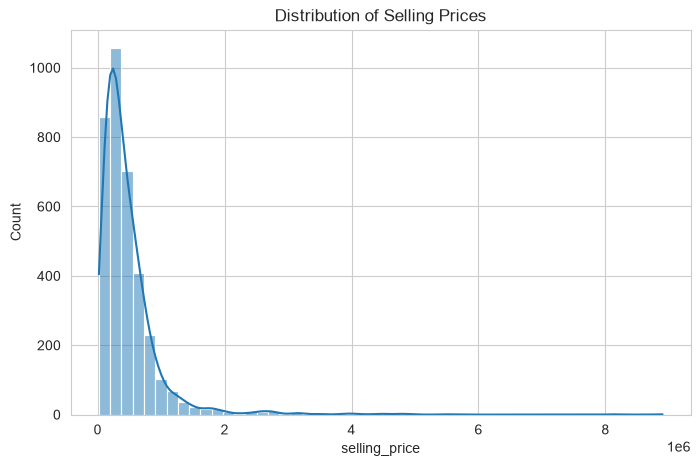

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['selling_price'], bins=50, kde=True)
plt.title("Distribution of Selling Prices")
plt.show()

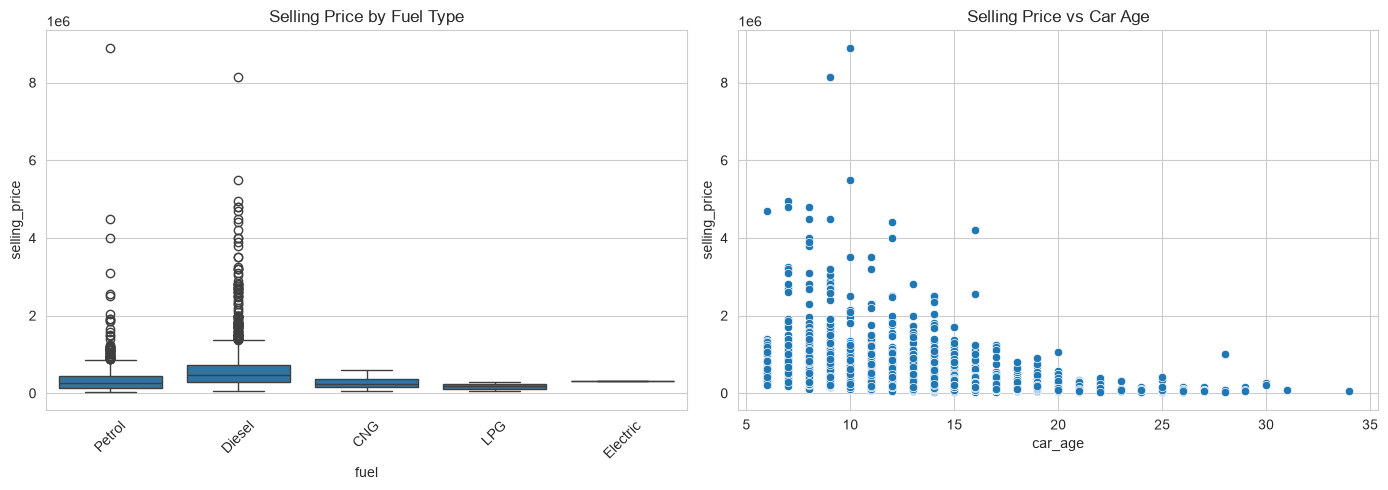

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='fuel', y='selling_price', data=df, ax=axes[0])
axes[0].set_title('Selling Price by Fuel Type')
axes[0].tick_params(axis='x', rotation=45)

sns.scatterplot(x='car_age', y='selling_price', data=df, ax=axes[1])
axes[1].set_title('Selling Price vs Car Age')

plt.tight_layout()
plt.show()

In [12]:
## Encoding Categorical Variables

In [13]:
df_encoded = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission', 'owner', 'brand'], drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (3577, 42)


,selling_price,km_driven,car_age,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_OpelCorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,60000,70000,19,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1,135000,50000,19,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,600000,100000,14,True,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3,250000,46000,9,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
4,450000,141000,12,True,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False


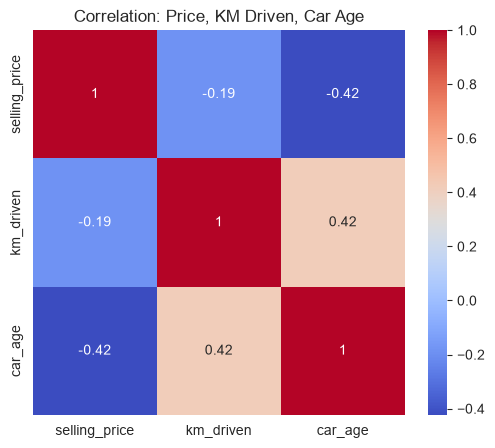

In [14]:
plt.figure(figsize=(6, 5))
sns.heatmap(df_encoded[['selling_price', 'km_driven', 'car_age']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation: Price, KM Driven, Car Age")
plt.show()

## Model Training

In [15]:
X = df_encoded.drop('selling_price', axis=1)
y = df_encoded['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (2861, 41) Test size: (716, 41)


In [16]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


In [17]:
models = {"Linear Regression": lr_model, "Random Forest": rf_model}
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"MAE: {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R² Score: {r2:.3f}")


Model: Linear Regression
MAE: 185,413.76
RMSE: 380,273.35
R² Score: 0.551

Model: Random Forest
MAE: 158,970.51
RMSE: 368,858.98
R² Score: 0.578


                             MAE           RMSE        R2
Linear Regression  185413.760184  380273.354725  0.551093
Random Forest      158970.507995  368858.975990  0.577638


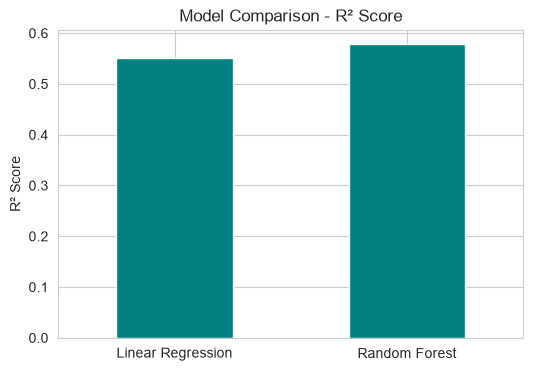

In [18]:
results_df = pd.DataFrame(results).T
print(results_df)

results_df[['R2']].plot(kind='bar', figsize=(6, 4), legend=False, color='teal')
plt.title("Model Comparison - R² Score")
plt.ylabel("R² Score")
plt.xticks(rotation=0)
plt.show()

Best performing model: Random Forest


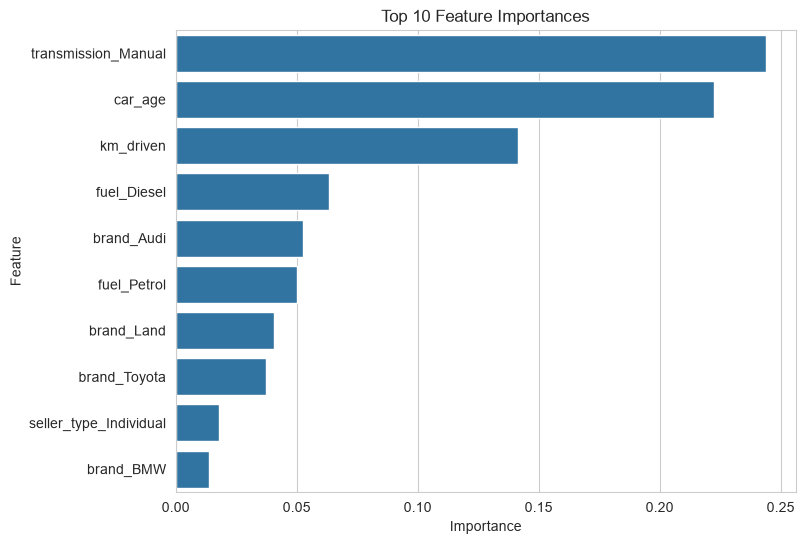

In [19]:
best_model_name = results_df['R2'].idxmax()
best_model = models[best_model_name]
print(f"Best performing model: {best_model_name}")

if best_model_name == "Random Forest":
    importance_df = pd.DataFrame({"Feature": X.columns, "Importance": best_model.feature_importances_})
    importance_df = importance_df.sort_values("Importance", ascending=False).head(10)

    plt.figure(figsize=(8, 6))
    sns.barplot(x="Importance", y="Feature", data=importance_df)
    plt.title("Top 10 Feature Importances")
    plt.show()
else:
    coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": best_model.coef_})
    print(coef_df.sort_values("Coefficient", ascending=False).head(10))

## Conclusion

Random Forest performed best among the two models tested. Transmission type 
(manual vs automatic), car age, and km_driven were the strongest predictors of 
selling price — older, higher-mileage manual cars tend to sell for less. Fuel 
type (diesel vs petrol) and brand (Audi, Toyota, Land Rover) also had a 
meaningful effect, reflecting how premium brands and diesel engines command 
higher resale value in the Indian used-car market.